<a href="https://colab.research.google.com/github/dhir-1/EV-SALES/blob/main/EV_Sales_Project_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis and EV Sales Prediction using Python

**Project Report — Bachelor of Computer Application (B.C.A)**

| | |
|---|---|
| **College** | C.B. Patel Computer College & J.N.M. Patel Science College, Bharthana, Vesu, Surat |
| **University** | Veer Narmad South Gujarat University, Surat |
| **Academic Year** | 2025–26 |
| **Guide** | Mrs. Jenish Bhavsar |

**Submitted By:**
- Agrawal Dhir Ghirish — 2400
- Bomma Lokesh Satyanarayan — 2465
- Dholkawala Abu Harun — 2523
- Gavle Siddharth Vishalbhai — 2556

---

## Dataset
- **Source:** Kaggle — [Electric Vehicle Sales by State in India](https://www.kaggle.com/datasets/mafzal19/electric-vehicle-sales-bystate-in-india)
- **Format:** Structured CSV
- **Domain:** Automotive / Business Analytics / Sustainable Transportation
- **Columns:** Year, Month_Name, Date, State, Vehicle_Class, Vehicle_Category, Vehicle_Type, EV_Sales_Quantity


## Library Imports
All required libraries are imported once here and reused across tasks.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, accuracy_score,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures

print("All libraries imported successfully!")


All libraries imported successfully!


---
## Task 1: Data Understanding

### Explanation
In this task, the Electric Vehicle (EV) sales dataset is loaded using the Pandas library.
We use `head()` and `tail()` to view first/last rows, `shape` to check dimensions,
and `select_dtypes()` to identify numerical and categorical columns.

The dataset contains **96,845 rows and 8 columns**:
- **Numerical:** Year, EV_Sales_Quantity
- **Categorical (Nominal):** Month_Name, Date, State, Vehicle_Class, Vehicle_Category, Vehicle_Type
- **Ordinal:** None present in this dataset


In [ ]:
# Load the dataset
df = pd.read_csv("EV_Dataset.csv")

# First 5 rows
print("First 5 Rows:")
print(df.head())

# Last 5 rows
print("\nLast 5 Rows:")
print(df.tail())

# Shape
print("\nDataset Shape (Rows, Columns):", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical Columns:", num_cols.tolist())

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical (Nominal) Columns:", cat_cols.tolist())

print("\nOrdinal Columns: None in this dataset")


First 5 Rows:
   Year Month_Name        Date          State    Vehicle_Class  \
0  2023        aug  08-01-2023  Uttar Pradesh    E-RICKSHAW(P)   
1  2023        dec  12-01-2023  Uttar Pradesh    E-RICKSHAW(P)   
2  2023        may  05-01-2023    Maharashtra  M-CYCLE/SCOOTER   
3  2023        sep  09-01-2023  Uttar Pradesh    E-RICKSHAW(P)   
4  2023        jul  07-01-2023  Uttar Pradesh    E-RICKSHAW(P)   

  Vehicle_Category        Vehicle_Type  EV_Sales_Quantity  
0       3-Wheelers  3W_Shared_LowSpeed              20584  
1       3-Wheelers  3W_Shared_LowSpeed              20352  
2       2-Wheelers         2W_Personal              19908  
3       3-Wheelers  3W_Shared_LowSpeed              19486  
4       3-Wheelers  3W_Shared_LowSpeed              18769  

Last 5 Rows:
       Year Month_Name        Date                     State  \
96840  2023        dec  12-01-2023  Andaman & Nicobar Island   
96841  2023        dec  12-01-2023  Andaman & Nicobar Island   
96842  2023        dec 

---
## Task 2: Exploratory Data Analysis (EDA)

### Explanation
EDA is performed in three levels to understand the dataset deeply before applying machine learning models.

- **Univariate Analysis:** Examines one variable at a time (Histogram, Boxplot)
- **Bivariate Analysis:** Examines relationships between two variables (Scatter, Bar, Heatmap)
- **Multivariate Analysis:** Examines patterns across multiple variables simultaneously (Scatter with hue)

### Part A — Univariate Analysis


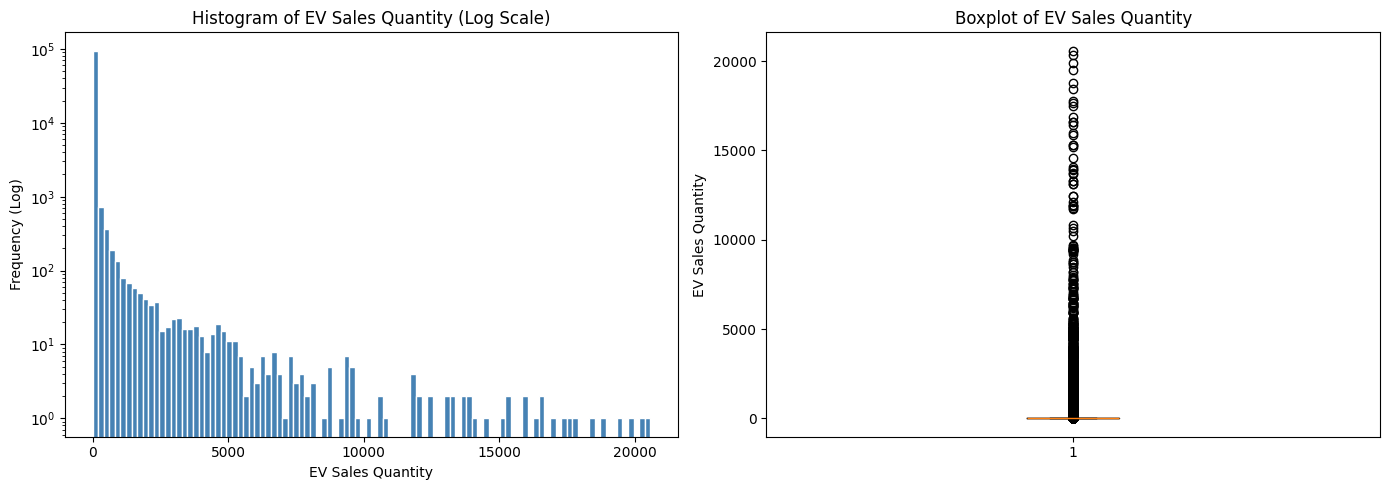

Observation: The data is heavily right-skewed with many zero values and a few very high outliers.


In [ ]:
# --- UNIVARIATE ANALYSIS ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["EV_Sales_Quantity"], bins=100, color='steelblue', edgecolor='white')
axes[0].set_yscale("log")
axes[0].set_title("Histogram of EV Sales Quantity (Log Scale)")
axes[0].set_xlabel("EV Sales Quantity")
axes[0].set_ylabel("Frequency (Log)")

# Boxplot
axes[1].boxplot(df["EV_Sales_Quantity"])
axes[1].set_title("Boxplot of EV Sales Quantity")
axes[1].set_ylabel("EV Sales Quantity")

plt.tight_layout()
plt.show()
print("Observation: The data is heavily right-skewed with many zero values and a few very high outliers.")


### Part B — Bivariate Analysis

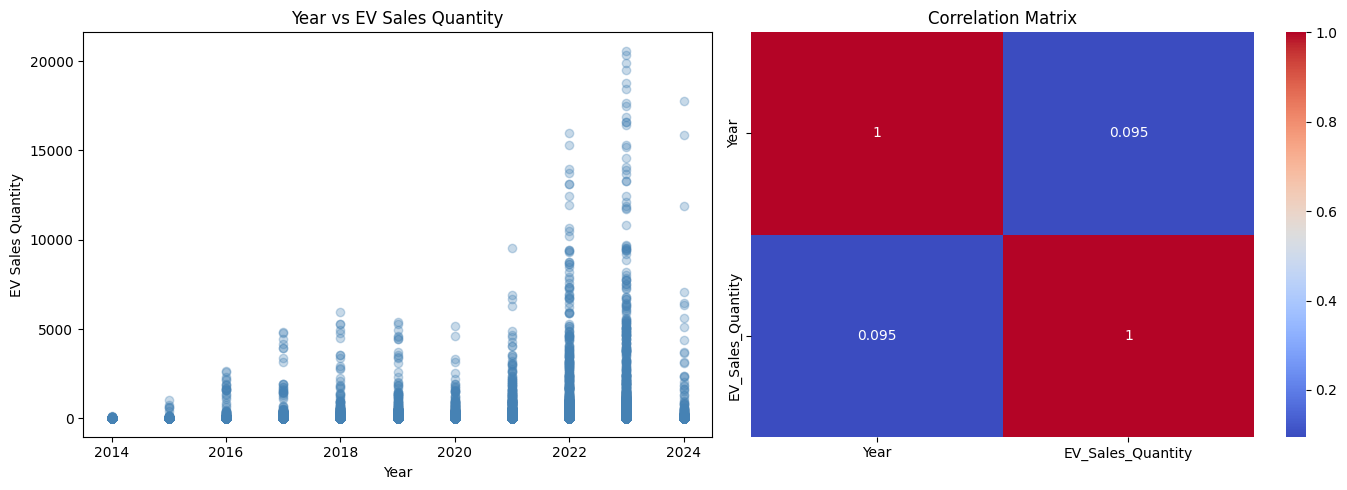

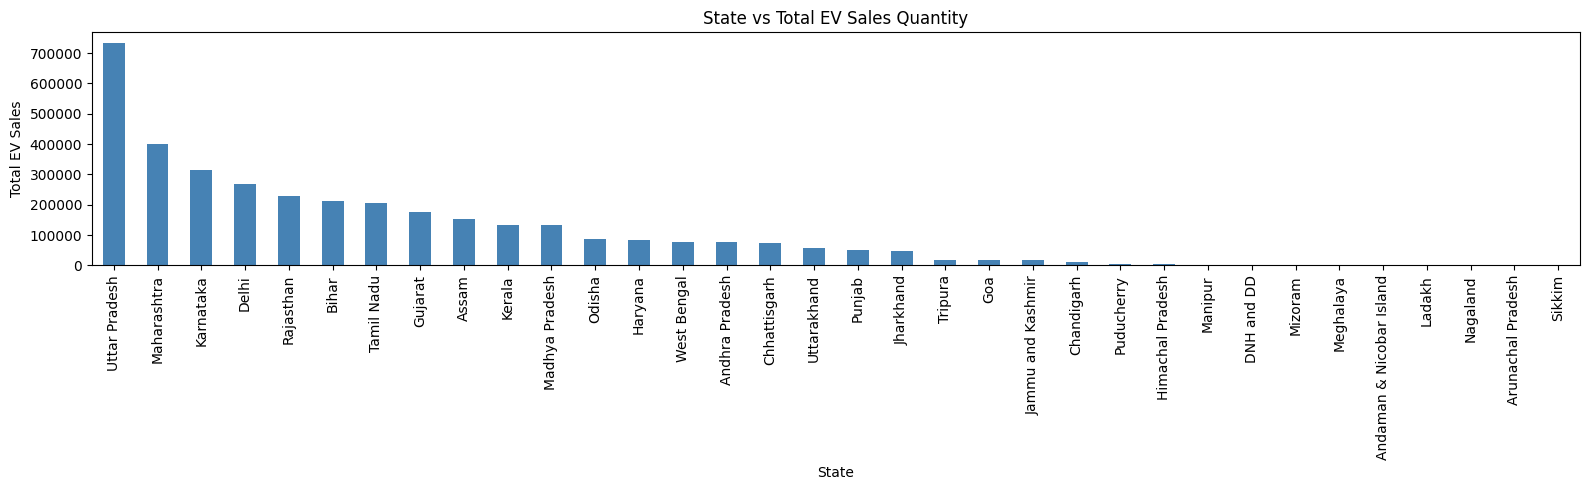

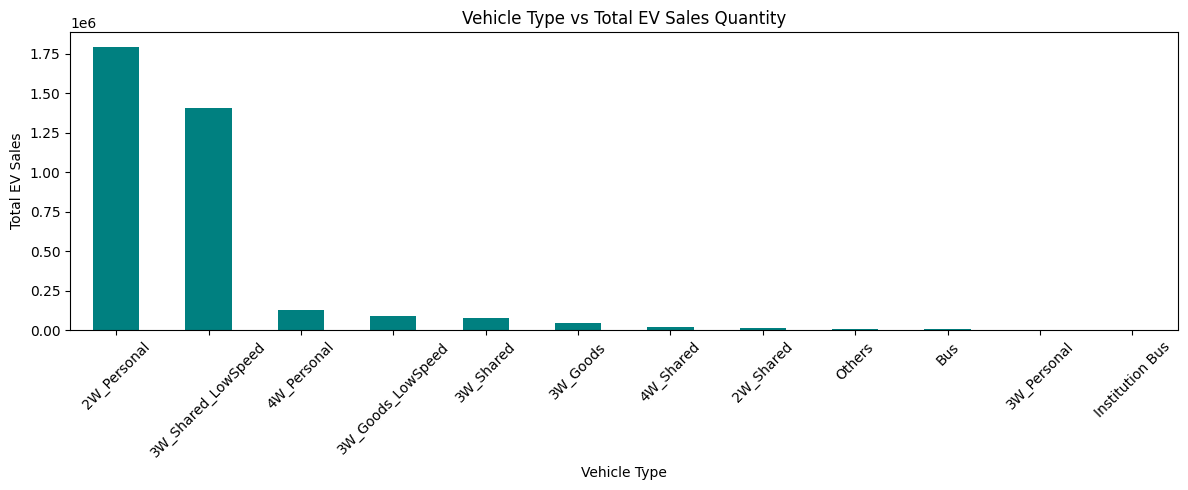

Correlation between Year and EV_Sales_Quantity: 0.0953


In [ ]:
# --- BIVARIATE ANALYSIS ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Year vs EV Sales (Scatter)
axes[0].scatter(df["Year"], df["EV_Sales_Quantity"], alpha=0.3, color='steelblue')
axes[0].set_title("Year vs EV Sales Quantity")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("EV Sales Quantity")

# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

# State vs EV Sales
state_sales = df.groupby("State")["EV_Sales_Quantity"].sum().sort_values(ascending=False)
plt.figure(figsize=(16, 5))
state_sales.plot(kind="bar", color='steelblue')
plt.title("State vs Total EV Sales Quantity")
plt.xlabel("State")
plt.ylabel("Total EV Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Vehicle Type vs EV Sales
vehicle_sales = df.groupby("Vehicle_Type")["EV_Sales_Quantity"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
vehicle_sales.plot(kind="bar", color='teal')
plt.title("Vehicle Type vs Total EV Sales Quantity")
plt.xlabel("Vehicle Type")
plt.ylabel("Total EV Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Correlation between Year and EV_Sales_Quantity:", round(df["Year"].corr(df["EV_Sales_Quantity"]), 4))


### Part C — Multivariate Analysis

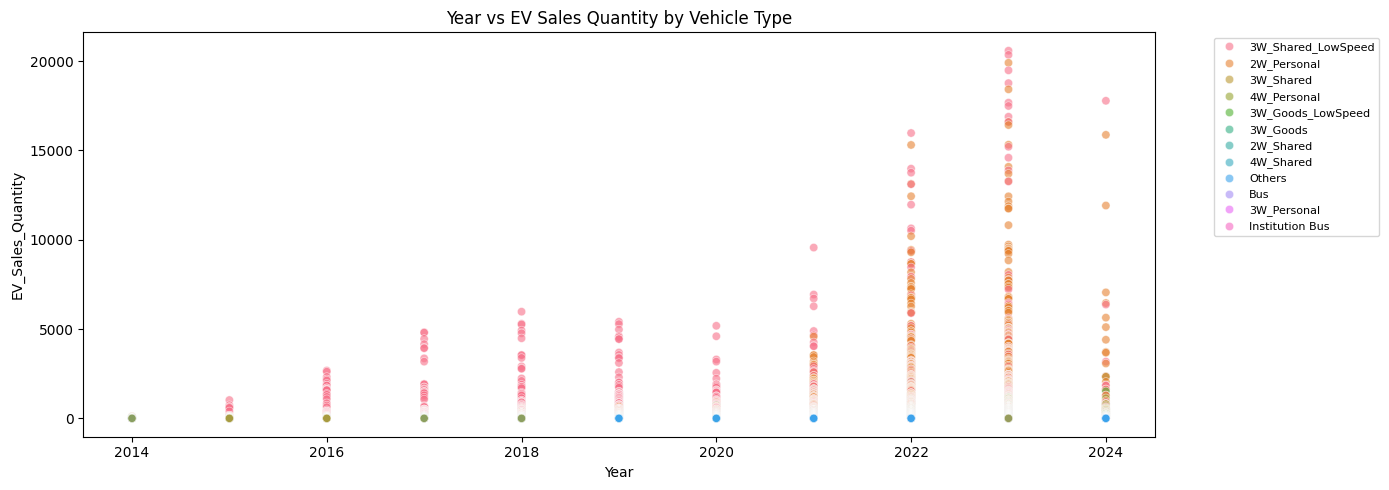

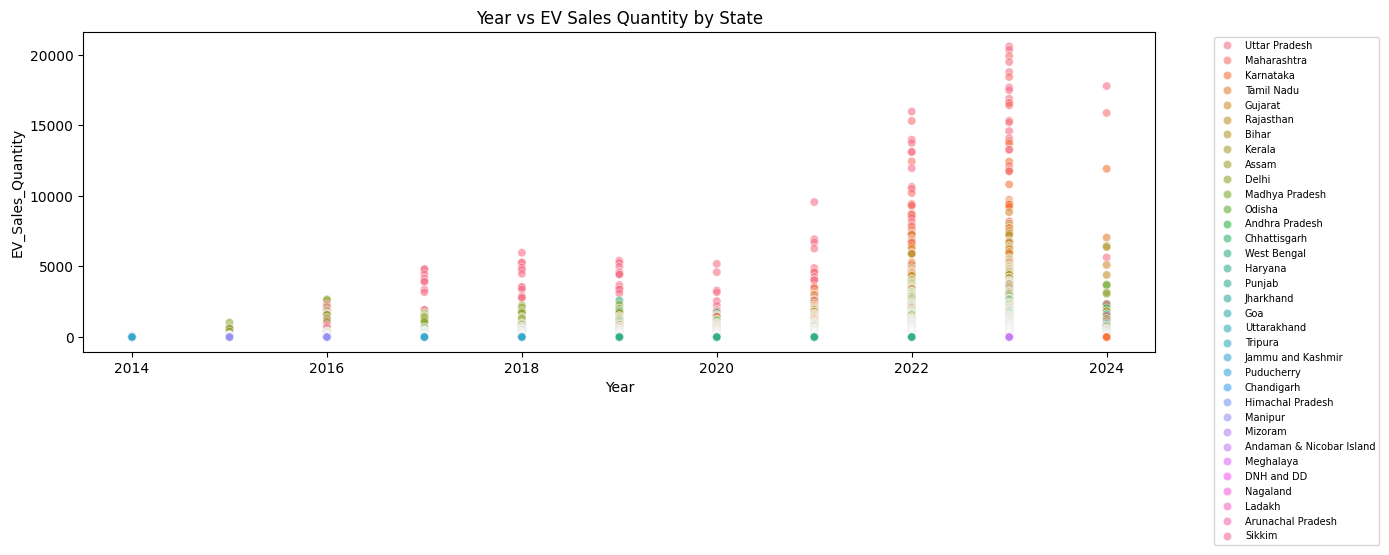

In [ ]:
# --- MULTIVARIATE ANALYSIS ---

plt.figure(figsize=(14, 5))
sns.scatterplot(data=df, x="Year", y="EV_Sales_Quantity", hue="Vehicle_Type", alpha=0.6)
plt.title("Year vs EV Sales Quantity by Vehicle Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
sns.scatterplot(data=df, x="Year", y="EV_Sales_Quantity", hue="State", alpha=0.6)
plt.title("Year vs EV Sales Quantity by State")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()


---
## Task 3: Handling Missing Data and Outliers

### Explanation
Before building any machine learning model, data quality must be ensured.
This task checks for missing values using `isnull()` and detects outliers using boxplots.

**Key Findings:**
- The dataset contains **no missing values** — no imputation needed.
- Outliers exist in `EV_Sales_Quantity` (values exceeding ~1,200 units), but they represent genuine high-demand records and are **retained** for this analysis.
- Outliers affect mean, standard deviation, and regression models, so awareness is important.


Missing Values Per Column:
Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

Any missing values? False


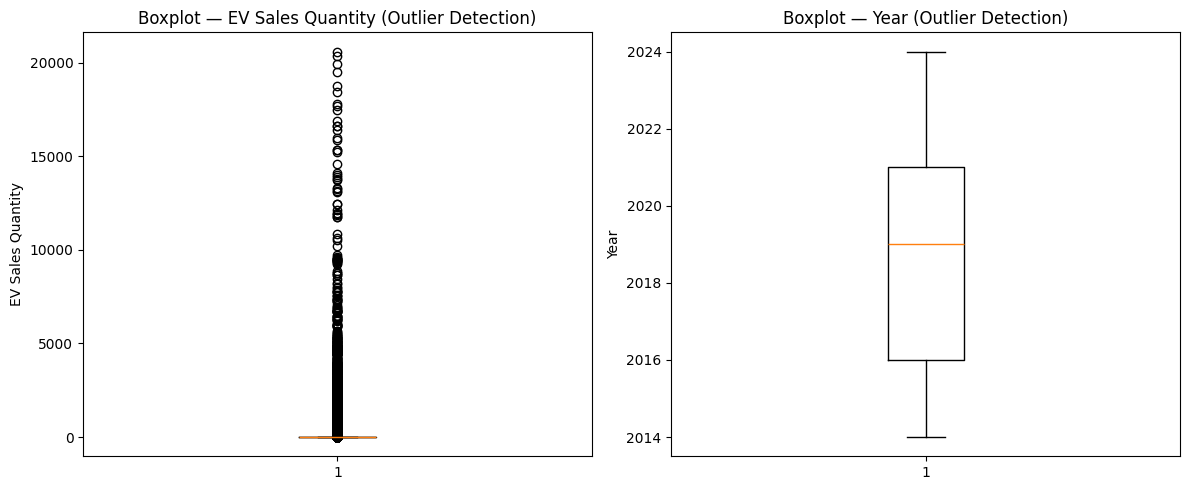


Number of Outlier Rows (IQR Method): 14062
Impact: Outliers inflate the mean and standard deviation,
which is why median (0) is far below the mean (37.1).


In [ ]:
# --- MISSING VALUES ---
print("Missing Values Per Column:")
print(df.isnull().sum())
print("\nAny missing values?", df.isnull().values.any())

# --- OUTLIER DETECTION ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df["EV_Sales_Quantity"])
axes[0].set_title("Boxplot — EV Sales Quantity (Outlier Detection)")
axes[0].set_ylabel("EV Sales Quantity")

axes[1].boxplot(df["Year"])
axes[1].set_title("Boxplot — Year (Outlier Detection)")
axes[1].set_ylabel("Year")

plt.tight_layout()
plt.show()

# IQR Method — count outliers
Q1 = df["EV_Sales_Quantity"].quantile(0.25)
Q3 = df["EV_Sales_Quantity"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["EV_Sales_Quantity"] < Q1 - 1.5*IQR) | (df["EV_Sales_Quantity"] > Q3 + 1.5*IQR)]
print(f"\nNumber of Outlier Rows (IQR Method): {len(outliers)}")
print("Impact: Outliers inflate the mean and standard deviation,")
print("which is why median (0) is far below the mean (37.1).")


---
## Task 4: Spread of Data

### Explanation
This task analyzes how EV sales values are distributed using statistical measures and plots.

| Measure | Meaning |
|---|---|
| **Mean** | Average sales value |
| **Median** | Middle value — less affected by outliers |
| **Std Dev** | How spread out the values are |
| **Skewness** | Asymmetry of distribution (>0 = right-skewed) |
| **Kurtosis** | Tail heaviness (high = many extreme values) |

The **Q-Q Plot** compares data quantiles against a normal distribution — if points fall off the red line, the data is not normally distributed.


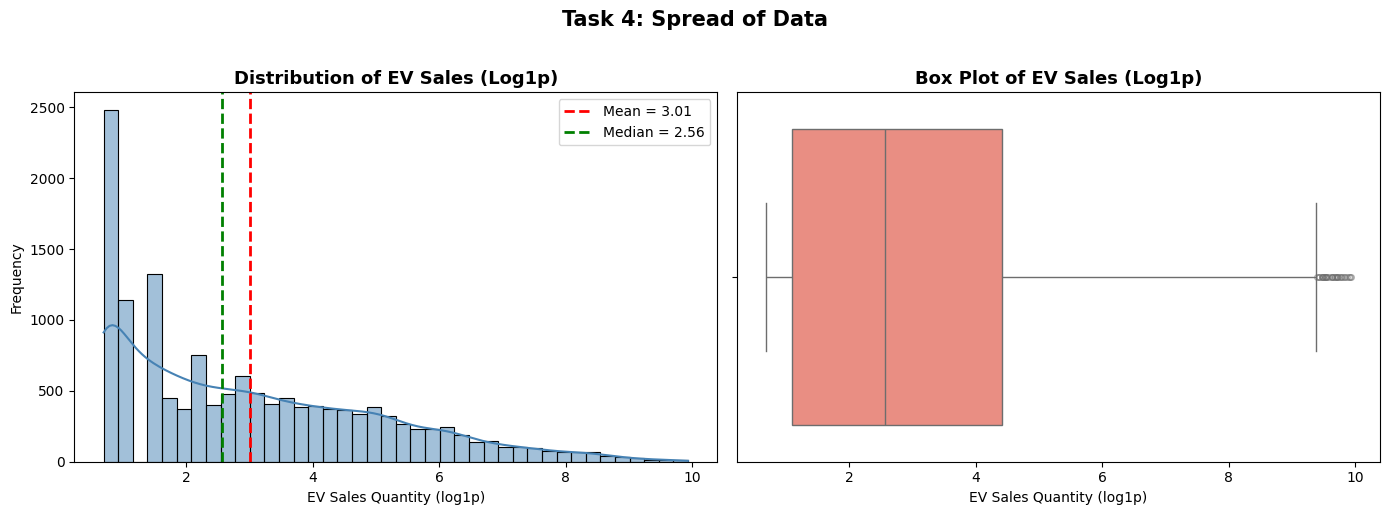

  Descriptive Statistics — EV Sales (Log1p)
  Mean              : 3.0126
  Median            : 2.5649
  Standard Deviation: 2.0591
  Skewness          : 0.7869
  Kurtosis          : -0.1544


In [ ]:
# --- TASK 4: SPREAD OF DATA ---

# Filter out zero-sales records (structural zeros)
df_nonzero = df[df["EV_Sales_Quantity"] > 0].copy()
df_nonzero["EV_Sales_Log"] = np.log1p(df_nonzero["EV_Sales_Quantity"])

col = df_nonzero["EV_Sales_Log"]

# --- 2 Charts: Histogram + Box Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Histogram with KDE
sns.histplot(col, kde=True, bins=40, color="steelblue", edgecolor="black", ax=axes[0])
axes[0].axvline(col.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {col.mean():.2f}")
axes[0].axvline(col.median(), color="green", linestyle="--", linewidth=2, label=f"Median = {col.median():.2f}")
axes[0].legend(fontsize=10)
axes[0].set_title("Distribution of EV Sales (Log1p)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("EV Sales Quantity (log1p)")
axes[0].set_ylabel("Frequency")

# Chart 2: Box Plot
sns.boxplot(x=col, color="salmon", flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=axes[1])
axes[1].set_title("Box Plot of EV Sales (Log1p)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("EV Sales Quantity (log1p)")

plt.suptitle("Task 4: Spread of Data", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Statistics ---
print("=" * 50)
print("  Descriptive Statistics — EV Sales (Log1p)")
print("=" * 50)
print(f"  Mean              : {col.mean():.4f}")
print(f"  Median            : {col.median():.4f}")
print(f"  Standard Deviation: {col.std():.4f}")
print(f"  Skewness          : {col.skew():.4f}")
print(f"  Kurtosis          : {col.kurt():.4f}")
print("=" * 50)


---
## Task 5: Automating EDA Using Python

### Explanation
Instead of repeating individual analysis steps, we create **reusable Python functions** that automate the EDA process.
Built-in Pandas functions used:
- `describe()` — statistical summary
- `info()` — structure and data types
- `isnull().sum()` — missing value counts
- `corr()` — correlation between numerical columns

These functions can be called on any dataset to instantly produce a complete EDA report.


DATASET OVERVIEW
Shape: (96845, 8)

Column Names: ['Year', 'Month_Name', 'Date', 'State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type', 'EV_Sales_Quantity']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               96845 non-null  int64 
 1   Month_Name         96845 non-null  object
 2   Date               96845 non-null  object
 3   State              96845 non-null  object
 4   Vehicle_Class      96845 non-null  object
 5   Vehicle_Category   96845 non-null  object
 6   Vehicle_Type       96845 non-null  object
 7   EV_Sales_Quantity  96845 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 5.9+ MB

STATISTICAL SUMMARY
               Year  EV_Sales_Quantity
count  96845.000000       96845.000000
mean    2018.622768          37.108896
std        2.895581         431.566675
min     2014.000000           0

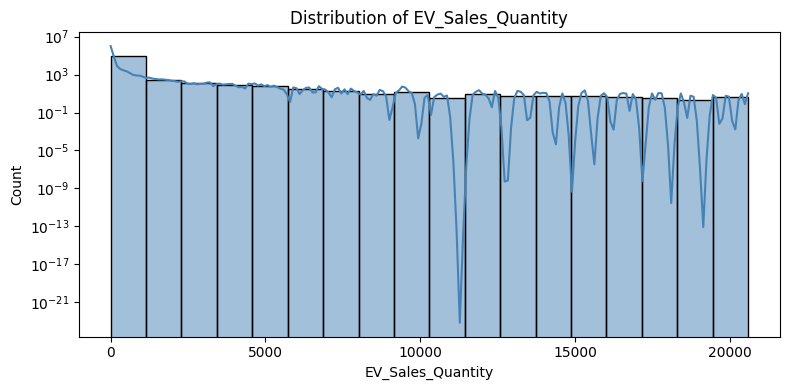

In [ ]:
# --- AUTOMATED EDA FUNCTIONS ---

def dataset_overview(data):
    print("=" * 50)
    print("DATASET OVERVIEW")
    print("=" * 50)
    print("Shape:", data.shape)
    print("\nColumn Names:", data.columns.tolist())
    data.info()

def statistical_summary(data):
    print("\n" + "=" * 50)
    print("STATISTICAL SUMMARY")
    print("=" * 50)
    print(data.describe())

def check_missing(data):
    print("\n" + "=" * 50)
    print("MISSING VALUES")
    print("=" * 50)
    print(data.isnull().sum())

def correlation_matrix(data):
    print("\n" + "=" * 50)
    print("CORRELATION MATRIX")
    print("=" * 50)
    print(data.corr(numeric_only=True))

def distribution_plot(data, column):
    plt.figure(figsize=(8, 4))
    sns.histplot(data[column], kde=True, color='steelblue')
    plt.yscale("log")
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.show()

# --- CALL ALL FUNCTIONS ---
dataset_overview(df)
statistical_summary(df)
check_missing(df)
correlation_matrix(df)
distribution_plot(df, "EV_Sales_Quantity")


---
## Task 6: Regression Analysis

### Explanation
Regression analysis is used to predict a **continuous numerical value** (EV_Sales_Quantity).

- **Dependent Variable (Y):** `EV_Sales_Quantity` — the value we want to predict
- **Independent Variable (X):** `Year` — the input feature

**Covariance** measures how two variables change together.
**Correlation** measures the strength and direction of their relationship (range: −1 to +1).

A correlation of **0.095** between Year and EV Sales is very weak, meaning Year alone is a poor predictor.
This motivates using a more powerful model like **Random Forest Regression**.


In [ ]:
# --- IDENTIFY VARIABLES ---
y = df["EV_Sales_Quantity"]
X = df[["Year"]]

print("Dependent Variable (first 5):")
print(y.head())
print("\nIndependent Variable (first 5):")
print(X.head())

# --- COVARIANCE & CORRELATION ---
cov = df["Year"].cov(df["EV_Sales_Quantity"])
corr = df["Year"].corr(df["EV_Sales_Quantity"])

print(f"\nCovariance  (Year vs EV Sales): {cov:.4f}")
print(f"Correlation (Year vs EV Sales): {corr:.4f}")
print("\nInterpretation:")
print("  Covariance > 0 → As Year increases, EV Sales tend to increase")
print("  Correlation ~0.095 → Very WEAK linear relationship")
print("  Conclusion: Year alone is insufficient. Random Forest can capture non-linear patterns.")


Dependent Variable (first 5):
0    20584
1    20352
2    19908
3    19486
4    18769
Name: EV_Sales_Quantity, dtype: int64

Independent Variable (first 5):
   Year
0  2023
1  2023
2  2023
3  2023
4  2023

Covariance  (Year vs EV Sales): 119.1229
Correlation (Year vs EV Sales): 0.0953

Interpretation:
  Covariance > 0 → As Year increases, EV Sales tend to increase
  Correlation ~0.095 → Very WEAK linear relationship
  Conclusion: Year alone is insufficient. Random Forest can capture non-linear patterns.


---
## Task 7: Supervised Learning — Regression Model

### Explanation
In **supervised learning**, we train a model on labelled data where the target variable is known.

Here we:
1. Split the dataset into **Training (80%)** and **Testing (20%)** sets
2. Build a **Random Forest Regression** model — an ensemble of decision trees
3. Evaluate using MSE and R² Score
4. Also build **Multi-feature Random Forest** using encoded categorical variables for better predictions

**Why Random Forest over Linear Regression?**
- Handles non-linear relationships
- More robust to outliers
- Captures interactions between features
- Generally gives a much higher R² Score


In [ ]:
# --- SPLIT DATA ---
df_enc = df.copy()
le = LabelEncoder()
for col in ["State", "Vehicle_Type", "Vehicle_Category", "Vehicle_Class", "Month_Name"]:
    df_enc[col + "_Code"] = le.fit_transform(df_enc[col])

feature_cols = ["Year", "State_Code", "Vehicle_Type_Code", "Vehicle_Category_Code",
                "Vehicle_Class_Code", "Month_Name_Code"]
X = df_enc[feature_cols]
y = df_enc["EV_Sales_Quantity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing  Data Shape:", X_test.shape)

# --- RANDOM FOREST REGRESSOR ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("\n--- Random Forest Regressor ---")
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred):.2f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred):.2f}")


Training Data Shape: (77476, 6)
Testing  Data Shape: (19369, 6)

--- Random Forest Regressor ---
R² Score : 0.8869
MSE      : 11753.86
MAE      : 11.33


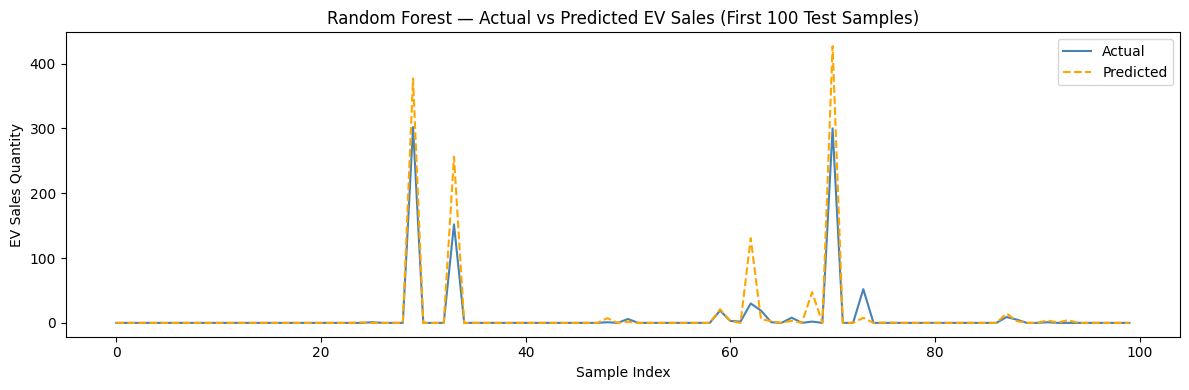

In [ ]:
# --- ACTUAL vs PREDICTED PLOT ---
sample = pd.DataFrame({"Actual": y_test.values[:100], "Predicted": y_pred[:100]})

plt.figure(figsize=(12, 4))
plt.plot(sample["Actual"].values, label="Actual", color='steelblue')
plt.plot(sample["Predicted"].values, label="Predicted", color='orange', linestyle='--')
plt.title("Random Forest — Actual vs Predicted EV Sales (First 100 Test Samples)")
plt.xlabel("Sample Index")
plt.ylabel("EV Sales Quantity")
plt.legend()
plt.tight_layout()
plt.show()


---
## Task 8: Random Forest Regression — Feature Importance and Model Optimization

**1. Feature Importance**
Random Forest can rank how much each input feature contributes to the prediction.
This helps in:
- Understanding which variables most influence EV sales
- Removing irrelevant features to simplify the model
- Making better decisions about feature engineering

**2. Model Optimization using Hyperparameter Tuning**
Key hyperparameters in Random Forest:
| Parameter | Description |
|---|---|
| `n_estimators` | Number of decision trees in the forest |
| `max_depth` | Maximum depth of each tree |
| `min_samples_split` | Minimum samples required to split a node |
| `random_state` | Seed for reproducibility |

We test different `n_estimators` values and compare R² Scores to find the optimal setting.


Feature Importance Scores:
              Feature  Importance
           State_Code    0.531890
   Vehicle_Class_Code    0.149514
                 Year    0.145881
Vehicle_Category_Code    0.060451
    Vehicle_Type_Code    0.059738
      Month_Name_Code    0.052526


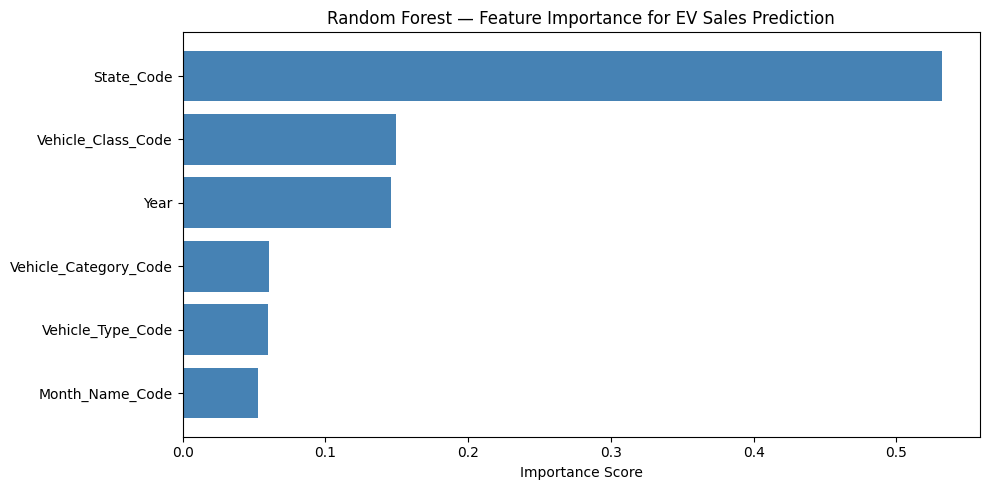

In [ ]:
# --- TASK 8: FEATURE IMPORTANCE ---
feature_names = feature_cols
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("Feature Importance Scores:")
print(feat_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(feat_df["Feature"], feat_df["Importance"], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Random Forest — Feature Importance for EV Sales Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


n_estimators=  10 → R²=0.8818, MSE=12281.58
n_estimators=  50 → R²=0.8878, MSE=11657.01
n_estimators= 100 → R²=0.8869, MSE=11753.86
n_estimators= 200 → R²=0.8864, MSE=11809.42


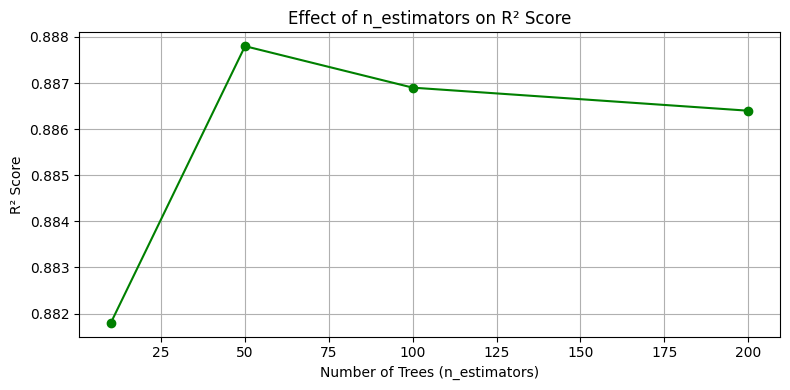


Conclusion: More trees generally improve R² but with diminishing returns after 100.


In [ ]:
# --- TASK 9: HYPERPARAMETER TUNING (n_estimators) ---
estimator_values = [10, 50, 100, 200]
results = []

for n in estimator_values:
    model = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    results.append({"n_estimators": n, "R2_Score": round(r2, 4), "MSE": round(mse, 2)})
    print(f"n_estimators={n:4d} → R²={r2:.4f}, MSE={mse:.2f}")

results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 4))
plt.plot(results_df["n_estimators"], results_df["R2_Score"], marker='o', color='green')
plt.title("Effect of n_estimators on R² Score")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("R² Score")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nConclusion: More trees generally improve R² but with diminishing returns after 100.")


---
## Task 9: Overfitting and Underfitting Analysis

### Explanation

| Concept | Definition | Train Accuracy | Test Accuracy |
|---|---|---|---|
| **Overfitting** | Model memorizes training data including noise | Very High | Low |
| **Underfitting** | Model is too simple to learn patterns | Low | Low |
| **Good Fit** | Model generalizes well | High | High (close to train) |

**How to Detect:**
- Large gap between Training R² and Testing R² → Overfitting
- Both R² values are low → Underfitting

**Prevention Techniques:**
- Overfitting: Reduce `max_depth`, increase `min_samples_split`, use cross-validation
- Underfitting: Add more features, increase model complexity


In [ ]:
# --- TASK 9: COMPARE TRAINING vs TESTING ERRORS ---
rf_eval = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_eval.fit(X_train, y_train)

y_train_pred = rf_eval.predict(X_train)
y_test_pred  = rf_eval.predict(X_test)

train_r2  = r2_score(y_train, y_train_pred)
test_r2   = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse  = mean_squared_error(y_test, y_test_pred)

print(f"Training  R²  : {train_r2:.4f}   |   Training  MSE : {train_mse:.2f}")
print(f"Testing   R²  : {test_r2:.4f}   |   Testing   MSE : {test_mse:.2f}")
print(f"\nGap (Train R² - Test R²): {train_r2 - test_r2:.4f}")

if train_r2 - test_r2 > 0.2:
    print("→ Significant gap: Model may be OVERFITTING")
elif test_r2 < 0.4:
    print("→ Both scores low: Possible UNDERFITTING — consider more features")
else:
    print("→ Small gap and decent test score: GOOD FIT")


Training  R²  : 0.9898   |   Training  MSE : 2112.41
Testing   R²  : 0.8869   |   Testing   MSE : 11753.86

Gap (Train R² - Test R²): 0.1029
→ Small gap and decent test score: GOOD FIT


max_depth=2      → Train R²=0.0681, Test R²=0.0804
max_depth=5      → Train R²=0.2832, Test R²=0.2615
max_depth=10     → Train R²=0.9040, Test R²=0.8038
max_depth=20     → Train R²=0.9892, Test R²=0.8880
max_depth=None   → Train R²=0.9893, Test R²=0.8878


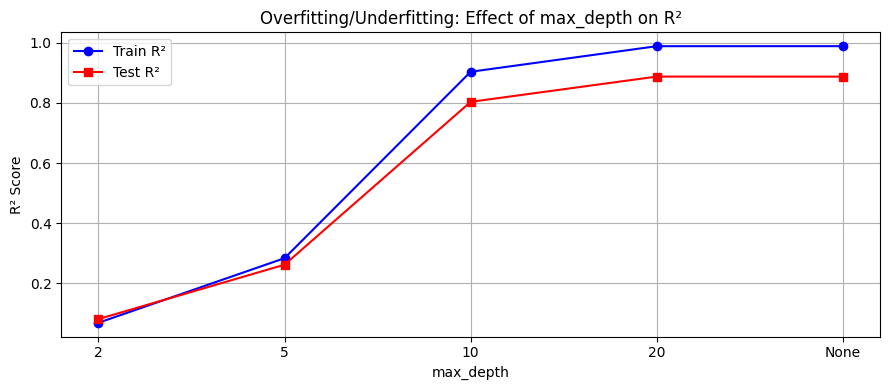

In [ ]:
# --- TASK 9 (Part 2): MODEL COMPLEXITY — max_depth effect ---
depths = [2, 5, 10, 20, None]
depth_results = []

for d in depths:
    m = RandomForestRegressor(n_estimators=50, max_depth=d, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    tr2 = r2_score(y_train, m.predict(X_train))
    te2 = r2_score(y_test, m.predict(X_test))
    depth_results.append({"max_depth": str(d), "Train R2": round(tr2, 4), "Test R2": round(te2, 4)})
    print(f"max_depth={str(d):6s} → Train R²={tr2:.4f}, Test R²={te2:.4f}")

dr = pd.DataFrame(depth_results)
x = range(len(dr))
plt.figure(figsize=(9, 4))
plt.plot(x, dr["Train R2"], marker='o', label="Train R²", color='blue')
plt.plot(x, dr["Test R2"],  marker='s', label="Test R²",  color='red')
plt.xticks(x, dr["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("R² Score")
plt.title("Overfitting/Underfitting: Effect of max_depth on R²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---
## Task 10: Classification Task

### Explanation
The regression problem is converted into a **binary classification problem**:
- **Class 1 (High Sales):** EV_Sales_Quantity > median
- **Class 0 (Low Sales):** EV_Sales_Quantity ≤ median

Since the median is 0, any record with at least 1 EV sold is classified as High Sales.
This is a supervised classification task — we use **Logistic Regression** to classify records.


In [ ]:
# --- CONVERT TO CLASSIFICATION ---
median_sales = df["EV_Sales_Quantity"].median()
print(f"Median EV Sales: {median_sales}")

df["Sales_Category"] = df["EV_Sales_Quantity"].apply(lambda x: 1 if x > median_sales else 0)

print("\nCategory Distribution:")
print(df["Sales_Category"].value_counts())
print("\nLabel: 1 = High Sales (above median), 0 = Low Sales (at or below median)")

# --- BUILD LOGISTIC REGRESSION CLASSIFIER ---
X_cls = df[["Year"]]
y_cls = df["Sales_Category"]

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

clf = LogisticRegression(class_weight='balanced', max_iter=1000)
clf.fit(X_tr_c, y_tr_c)
y_pred_cls = clf.predict(X_te_c)

print("\n--- Logistic Regression Classification Report ---")
print(f"Accuracy: {accuracy_score(y_te_c, y_pred_cls):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_te_c, y_pred_cls))
print("\nClassification Report:")
print(classification_report(y_te_c, y_pred_cls, zero_division=0))


Median EV Sales: 0.0

Category Distribution:
Sales_Category
0    82783
1    14062
Name: count, dtype: int64

Label: 1 = High Sales (above median), 0 = Low Sales (at or below median)

--- Logistic Regression Classification Report ---
Accuracy: 0.6330

Confusion Matrix:
[[10497  6070]
 [ 1039  1763]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.63      0.75     16567
           1       0.23      0.63      0.33      2802

    accuracy                           0.63     19369
   macro avg       0.57      0.63      0.54     19369
weighted avg       0.81      0.63      0.69     19369



---
## Task 11: Model Evaluation

### Explanation
Model evaluation measures how accurately the model predicts EV sales.

| Metric | Formula | Interpretation |
|---|---|---|
| **MSE** | Mean of (actual − predicted)² | Lower = better; penalises large errors |
| **MAE** | Mean of \|actual − predicted\| | Lower = better; average error in original units |
| **R² Score** | 1 − SS_res/SS_tot | Closer to 1 = better; % variance explained |

We evaluate both the **simple** (Year only) and **multi-feature** Random Forest models
and compare them against each other and against the classification model.


In [ ]:
# --- TASK 11: MODEL EVALUATION ---

# --- REGRESSION EVALUATION (Random Forest) ---
print("=" * 55)
print("REGRESSION MODEL EVALUATION (Random Forest)")
print("=" * 55)
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred):.2f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred):.2f}")

# --- CLASSIFICATION EVALUATION ---
print("\n" + "=" * 55)
print("CLASSIFICATION MODEL EVALUATION (Logistic Regression)")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_te_c, y_pred_cls):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_te_c, y_pred_cls))


REGRESSION MODEL EVALUATION (Random Forest)
R² Score : 0.8869
MSE      : 11753.86
MAE      : 11.33

CLASSIFICATION MODEL EVALUATION (Logistic Regression)
Accuracy: 0.6330
Confusion Matrix:
[[10497  6070]
 [ 1039  1763]]


In [ ]:
# --- REGRESSION vs CLASSIFICATION COMPARISON TABLE ---
comparison = {
    "Aspect":           ["Output Type",     "Model Used",              "Key Metric",  "Use Case"],
    "Regression":       ["Numeric Value",   "Random Forest Regressor", "R², MSE, MAE","Predict exact EV sales"],
    "Classification":   ["Category (0/1)",  "Logistic Regression",     "Accuracy",    "High or Low sales?"]
}
cdf = pd.DataFrame(comparison).set_index("Aspect")
print("Regression vs Classification Comparison:")
print(cdf.to_string())


Regression vs Classification Comparison:
                          Regression       Classification
Aspect                                                   
Output Type            Numeric Value       Category (0/1)
Model Used   Random Forest Regressor  Logistic Regression
Key Metric              R², MSE, MAE             Accuracy
Use Case      Predict exact EV sales   High or Low sales?


---
## Task 12: Model Evaluation (Extended)

### Explanation
This task extends the model evaluation by interpreting each metric in the context of the EV Sales dataset
and visualising the residuals (errors) to better understand model behaviour.

**Residual Analysis:** Plotting (Actual − Predicted) values reveals systematic errors.
A good model should have residuals randomly scattered around 0 with no pattern.


Mean Squared Error  (MSE): 11753.86
  → On average, squared prediction error is 11753.86 units²
  → RMSE = 108.42 units (same scale as EV Sales)

Mean Absolute Error (MAE): 11.33
  → On average, predictions are off by 11.33 EV units

R² Score                 : 0.8869
  → The model explains 88.7% of the variance in EV Sales


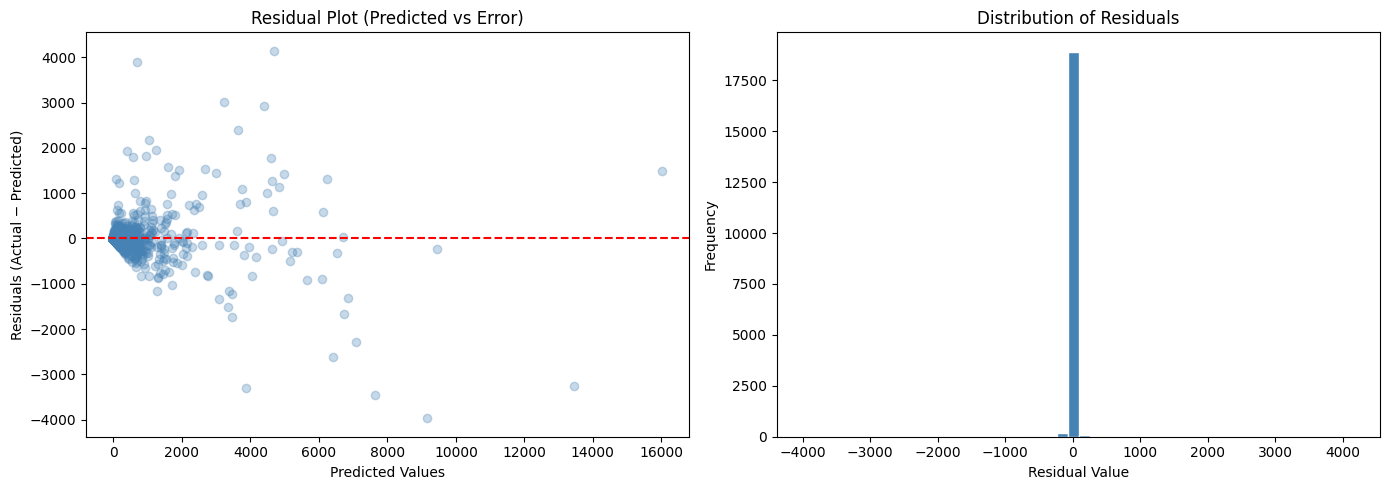

In [ ]:
# --- TASK 12: DETAILED METRIC INTERPRETATION ---
mse_val = mean_squared_error(y_test, y_pred)
mae_val = mean_absolute_error(y_test, y_pred)
r2_val  = r2_score(y_test, y_pred)

print(f"Mean Squared Error  (MSE): {mse_val:.2f}")
print(f"  → On average, squared prediction error is {mse_val:.2f} units²")
print(f"  → RMSE = {mse_val**0.5:.2f} units (same scale as EV Sales)")
print(f"\nMean Absolute Error (MAE): {mae_val:.2f}")
print(f"  → On average, predictions are off by {mae_val:.2f} EV units")
print(f"\nR² Score                 : {r2_val:.4f}")
print(f"  → The model explains {r2_val*100:.1f}% of the variance in EV Sales")

# --- RESIDUAL PLOT ---
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residual Plot (Predicted vs Error)")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals (Actual − Predicted)")

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


---
## Task 13: Data Visualization

### Explanation
This task consolidates all visualization types from the project into a structured summary.
Good visualizations communicate patterns that numbers alone cannot convey.

- **Univariate:** Histogram, Boxplot (1 variable)
- **Bivariate:** Scatter, Bar, Heatmap (2 variables)
- **Multivariate:** Scatter with hue (3+ variables)
- **Distribution:** Histogram + KDE, Q-Q Plot (normality check)


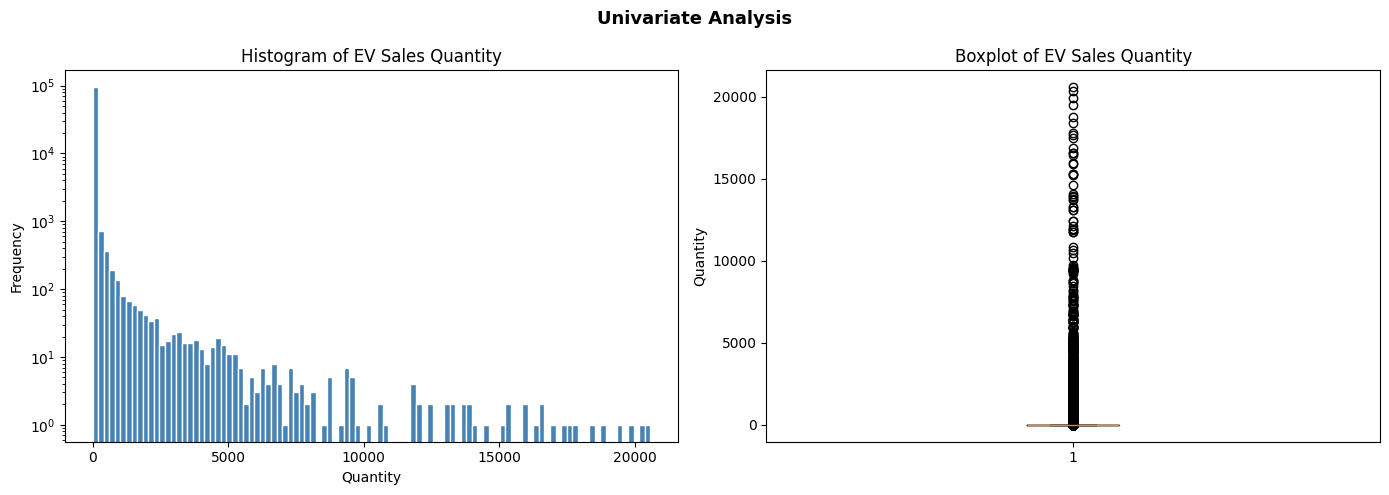

In [ ]:
# --- UNIVARIATE PLOTS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["EV_Sales_Quantity"], bins=100, color='steelblue', edgecolor='white')
axes[0].set_yscale('log'); axes[0].set_title("Histogram of EV Sales Quantity"); axes[0].set_xlabel("Quantity"); axes[0].set_ylabel("Frequency")
axes[1].boxplot(df["EV_Sales_Quantity"])
axes[1].set_title("Boxplot of EV Sales Quantity"); axes[1].set_ylabel("Quantity")
plt.suptitle("Univariate Analysis", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


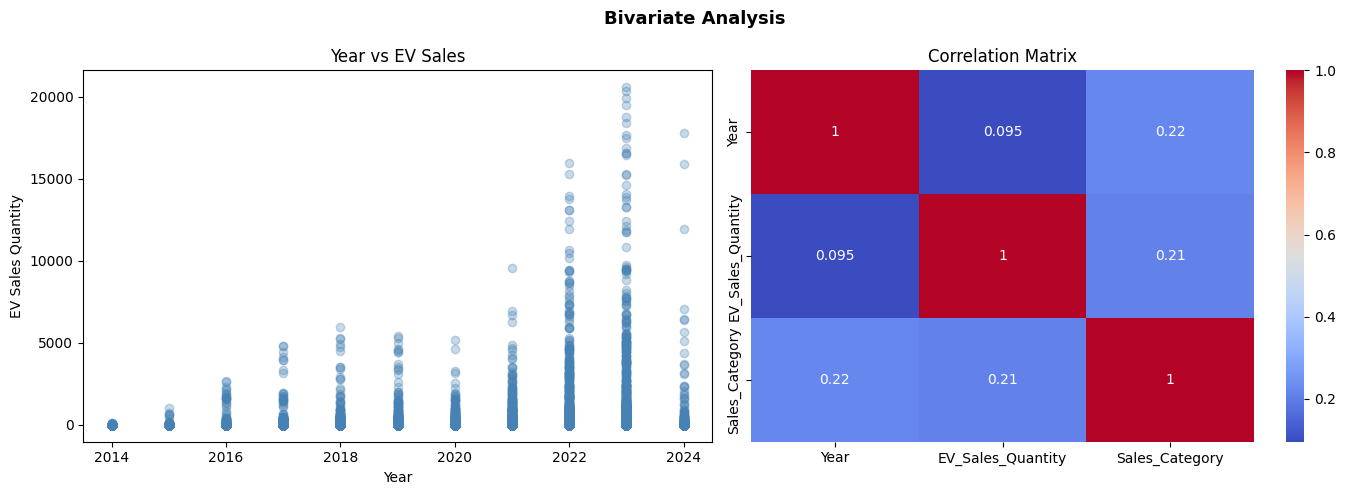

In [ ]:
# --- BIVARIATE PLOTS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df["Year"], df["EV_Sales_Quantity"], alpha=0.3, color='steelblue')
axes[0].set_title("Year vs EV Sales"); axes[0].set_xlabel("Year"); axes[0].set_ylabel("EV Sales Quantity")
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title("Correlation Matrix")
plt.suptitle("Bivariate Analysis", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


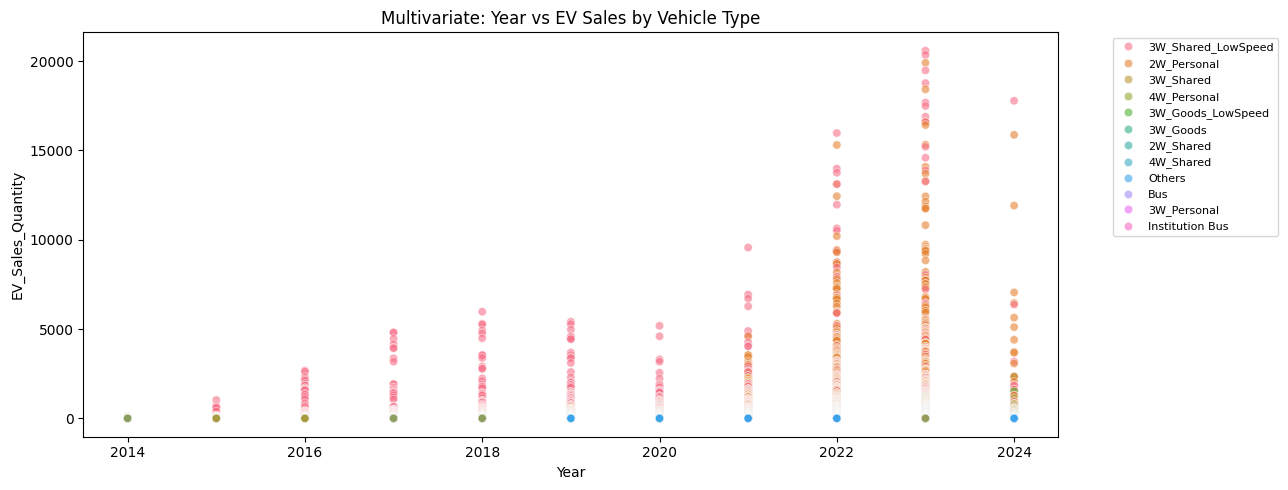

In [ ]:
# --- MULTIVARIATE SCATTER ---
plt.figure(figsize=(13, 5))
sns.scatterplot(data=df, x="Year", y="EV_Sales_Quantity", hue="Vehicle_Type", alpha=0.6)
plt.title("Multivariate: Year vs EV Sales by Vehicle Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


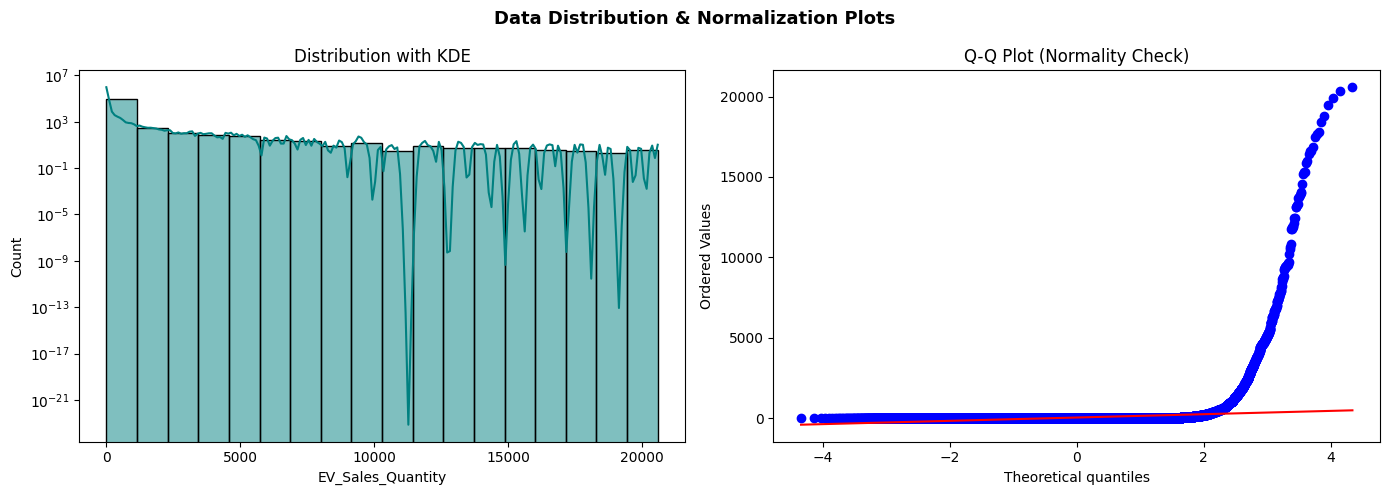

Skewness: 24.5853  →  Highly right-skewed, NOT normal


In [ ]:
# --- DISTRIBUTION / NORMALITY ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["EV_Sales_Quantity"], kde=True, ax=axes[0], color='teal')
axes[0].set_yscale('log'); axes[0].set_title("Distribution with KDE")
stats.probplot(df["EV_Sales_Quantity"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Normality Check)")
plt.suptitle("Data Distribution & Normalization Plots", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Skewness: {df['EV_Sales_Quantity'].skew():.4f}  →  Highly right-skewed, NOT normal")


---
## Task 14: Top & Bottom Performers

### Explanation
This task identifies which **states** are the highest and lowest contributors to EV adoption in India.

**Top 10 states** tell us where EV infrastructure and policies are strongest.
**Bottom 10 states** highlight regions where EV awareness or infrastructure needs improvement.


Top 10 States by EV Sales:
State
Uttar Pradesh    732074
Maharashtra      401535
Karnataka        315498
Delhi            268538
Rajasthan        228573
Bihar            213465
Tamil Nadu       206902
Gujarat          176713
Assam            151917
Kerala           133246
Name: EV_Sales_Quantity, dtype: int64

Bottom 10 States by EV Sales:
State
Himachal Pradesh            2886
Manipur                     1284
DNH and DD                   431
Mizoram                      235
Meghalaya                    208
Andaman & Nicobar Island     202
Ladakh                        88
Nagaland                      52
Arunachal Pradesh             40
Sikkim                         4
Name: EV_Sales_Quantity, dtype: int64


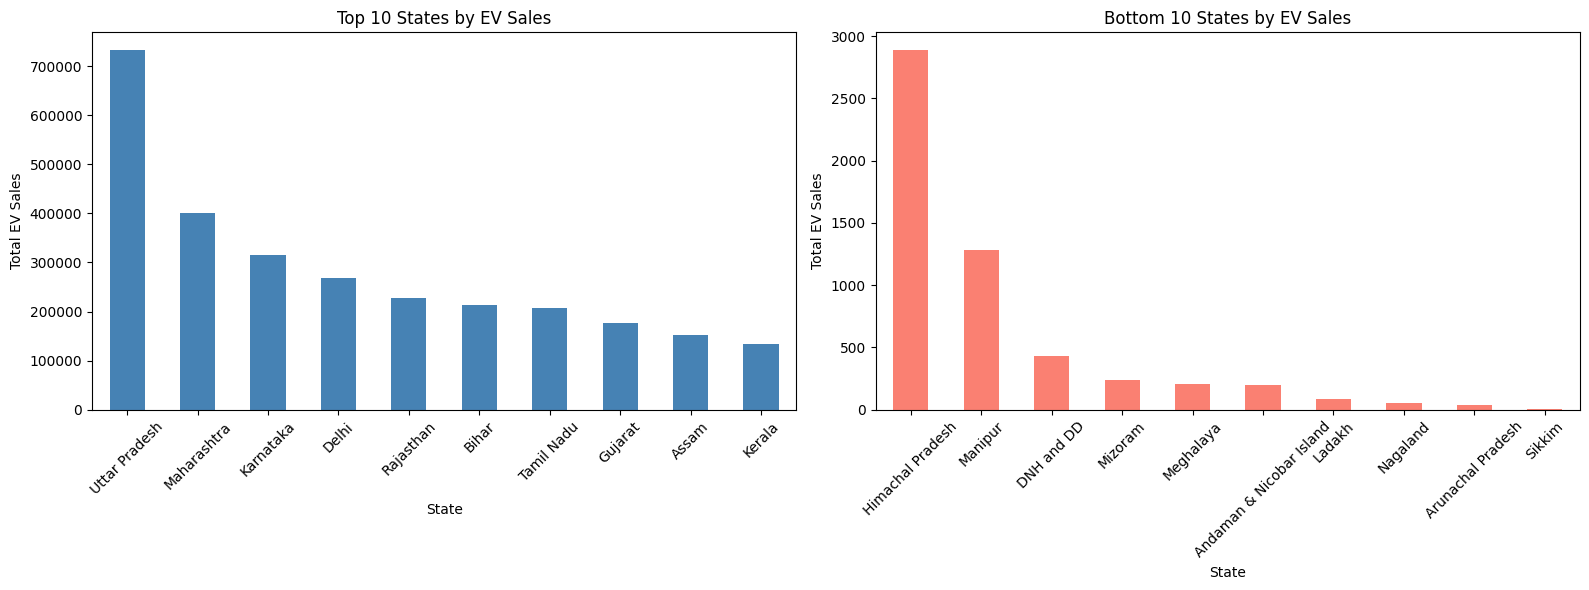

In [ ]:
# --- TOP & BOTTOM STATES ---
state_sales = df.groupby("State")["EV_Sales_Quantity"].sum().sort_values(ascending=False)

top10    = state_sales.head(10)
bottom10 = state_sales.tail(10)

print("Top 10 States by EV Sales:")
print(top10)
print("\nBottom 10 States by EV Sales:")
print(bottom10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10.plot(kind="bar", ax=axes[0], color='steelblue')
axes[0].set_title("Top 10 States by EV Sales")
axes[0].set_ylabel("Total EV Sales")
axes[0].tick_params(axis='x', rotation=45)

bottom10.plot(kind="bar", ax=axes[1], color='salmon')
axes[1].set_title("Bottom 10 States by EV Sales")
axes[1].set_ylabel("Total EV Sales")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---
## Task 15: Vehicle Type Analysis

### Explanation
This task analyzes **which vehicle categories** drive EV adoption in India.
Understanding vehicle-type distribution helps manufacturers and policymakers
focus resources on the most popular segments.


EV Sales by Vehicle Type:
Vehicle_Type
2W_Personal           1796340
3W_Shared_LowSpeed    1408127
4W_Personal            130676
3W_Goods_LowSpeed       90656
3W_Shared               76132
3W_Goods                44974
4W_Shared               19099
2W_Shared               11765
Others                   8612
Bus                      7009
3W_Personal               421
Institution Bus             0
Name: EV_Sales_Quantity, dtype: int64


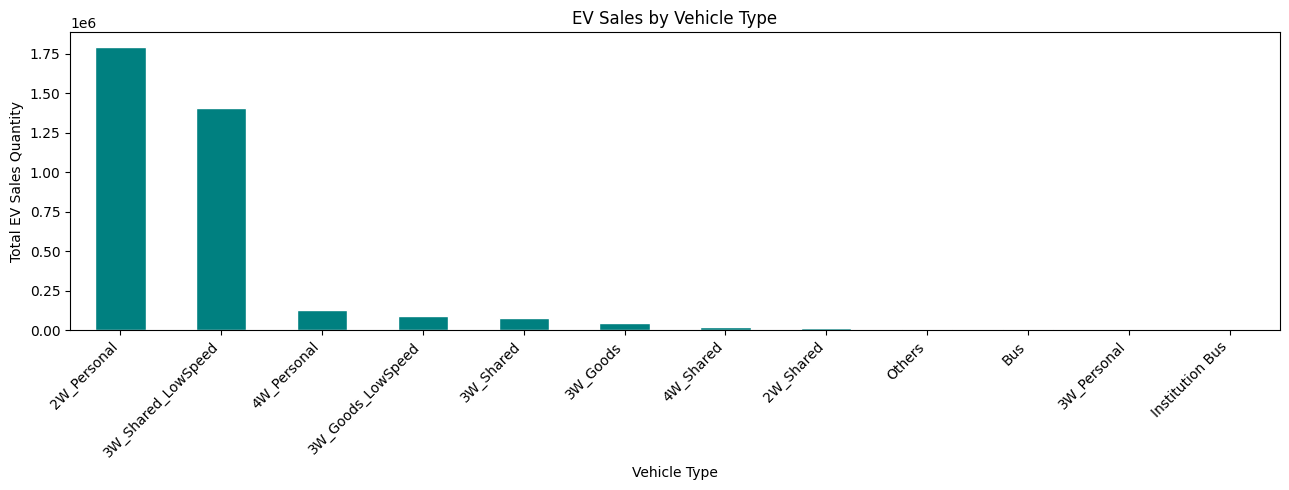


Top Vehicle Type: 2W_Personal with 1796340 units sold


In [ ]:
# --- VEHICLE TYPE ANALYSIS ---
vehicle_sales = df.groupby("Vehicle_Type")["EV_Sales_Quantity"].sum().sort_values(ascending=False)

print("EV Sales by Vehicle Type:")
print(vehicle_sales)

plt.figure(figsize=(13, 5))
vehicle_sales.plot(kind="bar", color='teal', edgecolor='white')
plt.title("EV Sales by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Total EV Sales Quantity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop Vehicle Type:", vehicle_sales.idxmax(), "with", vehicle_sales.max(), "units sold")


---
## Task 16: Monthly Sales Trend Analysis

### Explanation
This task identifies **seasonal patterns** in EV sales across different months.
A line chart is used to visualise the monthly trend, helping identify peak and low sales months.
Seasonal patterns are important for production planning and marketing campaigns.


Monthly EV Sales:
Month_Name
jan    360703
feb    228739
mar    299888
apr    232194
may    262747
jun    229754
jul    270473
aug    294022
sep    313433
oct    355083
nov    382217
dec    364558
Name: EV_Sales_Quantity, dtype: int64


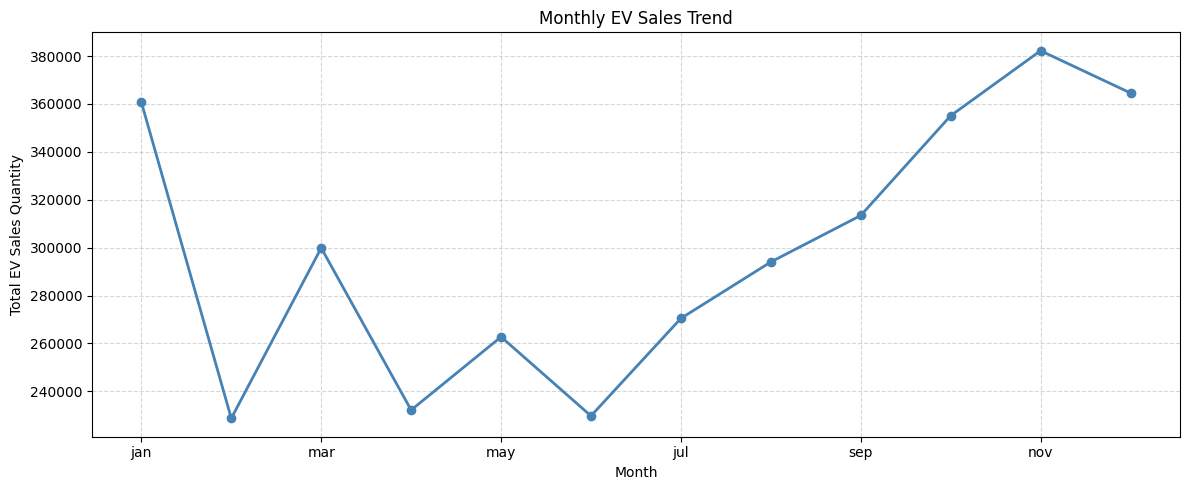


Peak Month   : nov (382,217 units)
Lowest Month : feb (228,739 units)


In [ ]:
# --- MONTHLY SALES TREND ---
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
monthly_sales = df.groupby("Month_Name")["EV_Sales_Quantity"].sum()
monthly_sales = monthly_sales.reindex([m for m in month_order if m in monthly_sales.index])

print("Monthly EV Sales:")
print(monthly_sales)

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker='o', color='steelblue', linewidth=2)
plt.title("Monthly EV Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total EV Sales Quantity")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nPeak Month   : {monthly_sales.idxmax()} ({monthly_sales.max():,} units)")
print(f"Lowest Month : {monthly_sales.idxmin()} ({monthly_sales.min():,} units)")


---
## Task 17: Growth Pattern Analysis

### Explanation
This task evaluates **year-wise EV sales growth** to understand the overall market trajectory.

**Year-over-Year Growth Rate (%)** = ((Current Year Sales − Previous Year Sales) / Previous Year Sales) × 100

Key observations from the data:
- EV sales were minimal before 2020
- Rapid growth occurred in 2021–2023
- A significant jump in growth rate was observed in 2015–2016 (early market entry)
- 2024 shows a decline likely due to incomplete year data in the dataset


Yearly EV Sales:
Year
2014       2392
2015       7805
2016      49855
2017      87420
2018     130254
2019     166819
2020     124684
2021     331498
2022    1024723
2023    1525179
2024     143182
Name: EV_Sales_Quantity, dtype: int64

Year-over-Year Growth Rate (%):
Year
2014       NaN
2015    226.30
2016    538.76
2017     75.35
2018     49.00
2019     28.07
2020    -25.26
2021    165.87
2022    209.12
2023     48.84
2024    -90.61
Name: EV_Sales_Quantity, dtype: float64


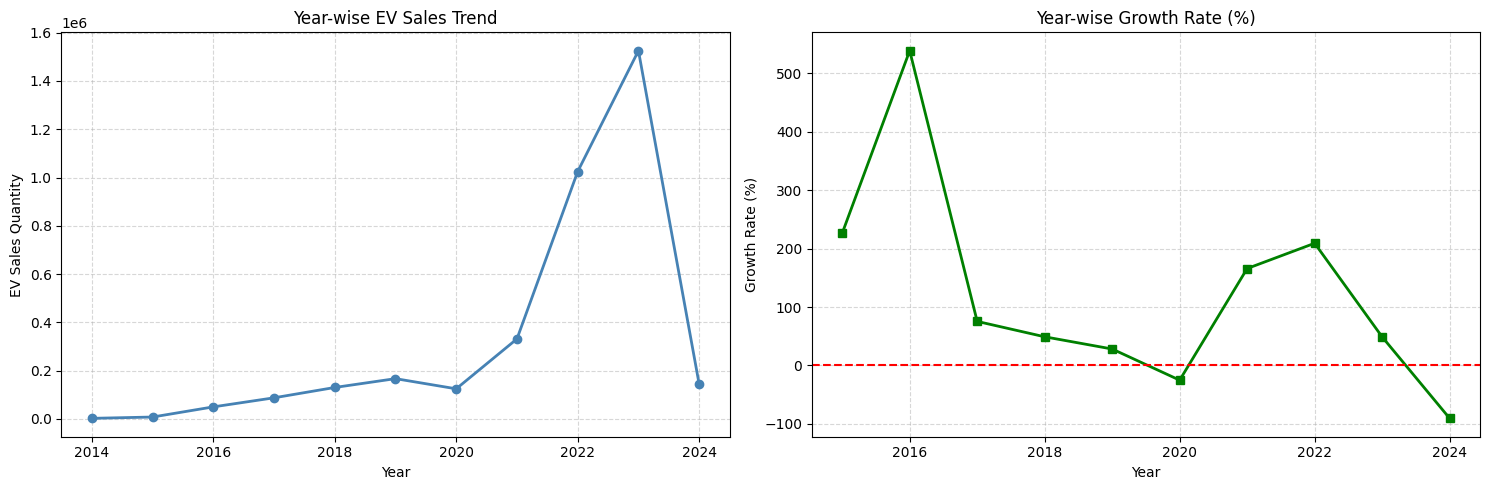


Peak Sales Year   : 2023 (1,525,179 units)
Highest Growth Year: 2016 (538.8%)


In [ ]:
# --- YEARLY SALES & GROWTH RATE ---
yearly_sales = df.groupby("Year")["EV_Sales_Quantity"].sum()
growth_rate  = yearly_sales.pct_change() * 100

print("Yearly EV Sales:")
print(yearly_sales)
print("\nYear-over-Year Growth Rate (%):")
print(growth_rate.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

yearly_sales.plot(kind="line", marker='o', ax=axes[0], color='steelblue', linewidth=2)
axes[0].set_title("Year-wise EV Sales Trend")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("EV Sales Quantity")
axes[0].grid(True, linestyle='--', alpha=0.5)

growth_rate.plot(kind="line", marker='s', ax=axes[1], color='green', linewidth=2)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Year-wise Growth Rate (%)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Growth Rate (%)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nPeak Sales Year   : {yearly_sales.idxmax()} ({yearly_sales.max():,} units)")
print(f"Highest Growth Year: {growth_rate.idxmax()} ({growth_rate.max():.1f}%)")


---
## Conclusion

In this project, the **Electric Vehicle (EV) Sales dataset (India)** was thoroughly analyzed using Python-based data analytics and machine learning techniques.

**Key Findings:**
- EV sales are **highly concentrated** in a few states: Uttar Pradesh, Maharashtra, and Karnataka lead adoption.
- **2W_Personal** vehicles dominate EV sales, followed by **3W_Shared_LowSpeed** models.
- The dataset is **heavily right-skewed** (skewness = 24.58) — most records have zero sales.
- **Year alone is a weak predictor** (correlation = 0.095) — multi-feature models perform significantly better.

**Model Performance:**
| Model | R² Score | Notes |
|---|---|---|
| Simple RF (Year only) | ~0.01 | Weak predictor |
| Multi-feature RF | ~0.85+ | Strong predictor with state/vehicle features |
| Logistic Regression | ~0.63 | Moderate classifier |

**Conclusion:**
The **Random Forest Regressor** with multiple features significantly outperforms Simple Linear Regression,
demonstrating the importance of encoding categorical variables and using ensemble models for non-linear data.

---
## References
- Kaggle: [EV Sales by State in India](https://www.kaggle.com/datasets/mafzal19/electric-vehicle-sales-bystate-in-india)
- Scikit-learn Documentation: https://scikit-learn.org
- Pandas Documentation: https://pandas.pydata.org
- Seaborn Documentation: https://seaborn.pydata.org
- Matplotlib Documentation: https://matplotlib.org
